
      Rat Oblique: n=  978, mean=0.245 ± 0.103
          Rat DGC: n= 1248, mean=0.183 ± 0.088
    Mouse Oblique: n= 1046, mean=0.423 ± 0.177
        Mouse DGC: n= 1981, mean=0.155 ± 0.072
    Human Oblique: n=  460, mean=0.408 ± 0.177


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

        Human DGC: n=  752, mean=0.231 ± 0.106

Saved: z_extent_normalized_all.csv (6465 neurons)

  Rat: oblique (n=978) vs DGC (n=1248), U=830770, p=1.12e-48
  Mouse: oblique (n=1046) vs DGC (n=1981), U=1937263, p=0.00e+00
  Human: oblique (n=460) vs DGC (n=752), U=279200, p=3.15e-72


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

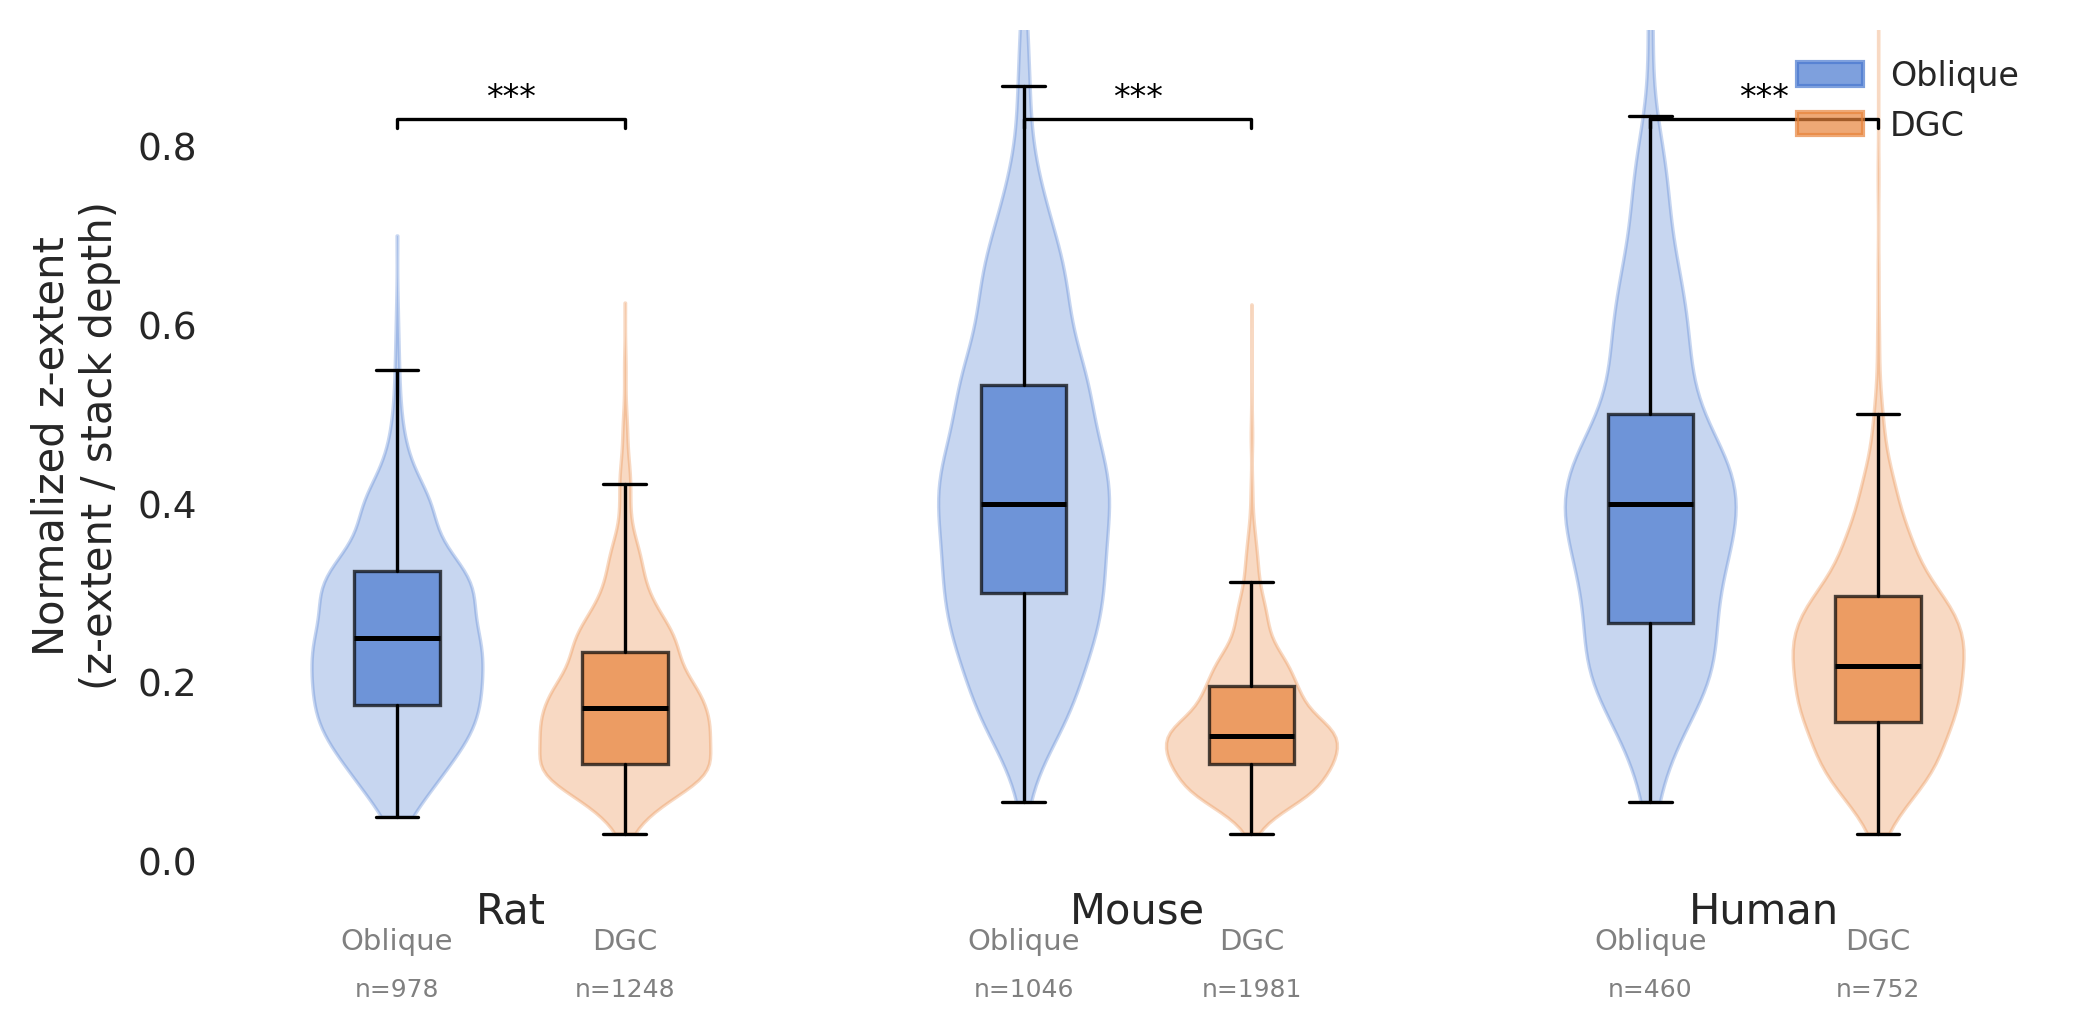


Saved: fig_z_extent_normalized.pdf / .png
Auto ylim: 0.93 (data max=0.800)


In [2]:
"""
fig_z_extent.py — Normalized z-extent violin/box plot for MIA Figure.

Reads 3D instance masks, computes per-neuron z-extent / stack_depth,
saves raw data to CSV, produces a publication-quality figure.

Usage:
    python fig_z_extent.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from pathlib import Path
from tifffile import imread
from scipy.stats import mannwhitneyu

# ═══════════════════════════════════════════════════════════════════════════
#  CONFIG
# ═══════════════════════════════════════════════════════════════════════════

BASE = Path("/NAS/mmaiurov/datasets_benchmark")

DATASETS = {
    "Rat\nOblique":   ("rat_neurons_oblique",   "Oblique", "Rat"),
    "Rat\nDGC":       ("rat_neurons_dodt",      "DGC",     "Rat"),
    "Mouse\nOblique": ("mice_neurons_oblique",  "Oblique", "Mouse"),
    "Mouse\nDGC":     ("mice_neurons_dodt",     "DGC",     "Mouse"),
    "Human\nOblique": ("human_neurons_oblique", "Oblique", "Human"),
    "Human\nDGC":     ("human_neurons_dodt",    "DGC",     "Human"),
}

# ═══════════════════════════════════════════════════════════════════════════
#  DATA COLLECTION
# ═══════════════════════════════════════════════════════════════════════════

print("Collecting z-extent data from masks...\n")

data = {}
csv_rows = []

for label, (folder, modality, species) in DATASETS.items():
    mask_dir = BASE / folder / "masks"
    z_extents_norm = []

    for f in sorted(mask_dir.glob("*.tif")):
        vol = imread(str(f))
        stack_depth = vol.shape[0]
        labels_in_vol = np.unique(vol)
        labels_in_vol = labels_in_vol[labels_in_vol != 0]

        for lbl in labels_in_vol:
            zz = np.where(np.any(vol == lbl, axis=(1, 2)))[0]
            if len(zz) < 2:
                continue
            z_ext_slices = zz[-1] - zz[0] + 1
            z_ext_norm = z_ext_slices / stack_depth
            z_extents_norm.append(z_ext_norm)
            csv_rows.append({
                "species": species,
                "modality": modality,
                "dataset": folder,
                "file": f.name,
                "neuron_id": int(lbl),
                "z_extent_slices": z_ext_slices,
                "stack_depth": stack_depth,
                "z_extent_normalized": z_ext_norm,
            })

    data[label] = np.array(z_extents_norm)
    print(f"  {label.replace(chr(10), ' '):>15s}: n={len(z_extents_norm):5d}, "
          f"mean={np.mean(z_extents_norm):.3f} ± {np.std(z_extents_norm):.3f}")

# ═══════════════════════════════════════════════════════════════════════════
#  SAVE CSV
# ═══════════════════════════════════════════════════════════════════════════

csv_df = pd.DataFrame(csv_rows)
csv_path = "z_extent_normalized_all.csv"
csv_df.to_csv(csv_path, index=False)
print(f"\nSaved: {csv_path} ({len(csv_df)} neurons)")

# ═══════════════════════════════════════════════════════════════════════════
#  STATISTICAL TESTS
# ═══════════════════════════════════════════════════════════════════════════

species_list = ["Rat", "Mouse", "Human"]
pvalues = {}
print()
for sp in species_list:
    obl = data[f"{sp}\nOblique"]
    dgc = data[f"{sp}\nDGC"]
    U, p = mannwhitneyu(obl, dgc, alternative='two-sided')
    pvalues[sp] = p
    print(f"  {sp}: oblique (n={len(obl)}) vs DGC (n={len(dgc)}), U={U:.0f}, p={p:.2e}")

# ═══════════════════════════════════════════════════════════════════════════
#  FIGURE
# ═══════════════════════════════════════════════════════════════════════════

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

COLOR_OBL = "#4878CF"
COLOR_DGC = "#E8833A"

fig, ax = plt.subplots(figsize=(7, 3.5))

labels_order = []
for sp in species_list:
    labels_order.append(f"{sp}\nOblique")
    labels_order.append(f"{sp}\nDGC")

positions = []
pos = 0
for i, sp in enumerate(species_list):
    positions.append(pos)
    positions.append(pos + 0.8)
    pos += 2.2

# Violins
for i, label in enumerate(labels_order):
    color = COLOR_OBL if "Oblique" in label else COLOR_DGC
    vp = ax.violinplot(
        data[label],
        positions=[positions[i]],
        widths=0.6,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.3)
        body.set_edgecolor(color)
        body.set_linewidth(0.8)

# Boxplots
bp_data = [data[label] for label in labels_order]
bp_colors = [COLOR_OBL if "Oblique" in l else COLOR_DGC for l in labels_order]

bp = ax.boxplot(
    bp_data,
    positions=positions,
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
)

for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Auto ylim: based on data max + room for brackets
all_values = np.concatenate([data[l] for l in labels_order])
data_max = np.percentile(all_values, 99.5)
bracket_room = 0.08
ylim_top = data_max + bracket_room + 0.05
bracket_y = data_max + 0.02

# Significance brackets
def add_significance(ax, x1, x2, y, p, dy=0.01):
    if p < 1e-10:
        stars = "***"
    elif p < 1e-3:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "n.s."
    ax.plot([x1, x1, x2, x2], [y, y + dy, y + dy, y], lw=0.8, color='black')
    ax.text((x1 + x2) / 2, y + dy + 0.005, stars,
            ha='center', va='bottom', fontsize=8, color='black')

for i, sp in enumerate(species_list):
    x1 = positions[i * 2]
    x2 = positions[i * 2 + 1]
    add_significance(ax, x1, x2, bracket_y, pvalues[sp])

# Formatting
ax.set_ylabel("Normalized z-extent\n(z-extent / stack depth)")
ax.set_xticks([positions[i * 2] + 0.4 for i in range(len(species_list))])
ax.set_xticklabels(species_list, fontsize=10)

for i in range(len(labels_order)):
    modality_label = "Oblique" if "Oblique" in labels_order[i] else "DGC"
    ax.text(positions[i], -0.08, modality_label,
            ha='center', va='top', fontsize=7, color='gray',
            transform=ax.get_xaxis_transform())

ax.set_ylim(0, ylim_top)
ax.set_xlim(-0.6, positions[-1] + 0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=COLOR_OBL, alpha=0.7, edgecolor=COLOR_OBL, label='Oblique'),
    Patch(facecolor=COLOR_DGC, alpha=0.7, edgecolor=COLOR_DGC, label='DGC'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

for i, label in enumerate(labels_order):
    n = len(data[label])
    ax.text(positions[i], -0.14, f"n={n}",
            ha='center', va='top', fontsize=6, color='gray',
            transform=ax.get_xaxis_transform())

plt.tight_layout()
plt.savefig("fig_z_extent_normalized.pdf", bbox_inches='tight')
plt.savefig("fig_z_extent_normalized.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"\nSaved: fig_z_extent_normalized.pdf / .png")
print(f"Auto ylim: {ylim_top:.2f} (data max={data_max:.3f})")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

Loaded 6465 neurons from z_extent_normalized_all.csv
Species: ['Rat' 'Mouse' 'Human']
Modalities: ['Oblique' 'DGC']
  Rat Oblique: n=978, mean=0.245 ± 0.103, max=0.700
  Rat DGC: n=1248, mean=0.183 ± 0.088, max=0.625
  Mouse Oblique: n=1046, mean=0.423 ± 0.177, max=1.000
  Mouse DGC: n=1981, mean=0.155 ± 0.072, max=0.623
  Human Oblique: n=460, mean=0.408 ± 0.177, max=1.000
  Human DGC: n=752, mean=0.231 ± 0.106, max=1.000
  Rat: U=830770, p=1.12e-48
  Mouse: U=1937263, p=0.00e+00
  Human: U=279200, p=3.15e-72

Auto ylim: [0, 1.10] (max whisker: 0.883)


findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the following families were found: Arial, Helvetica
findfont: Generic family 'sans-serif' not found because none of the foll

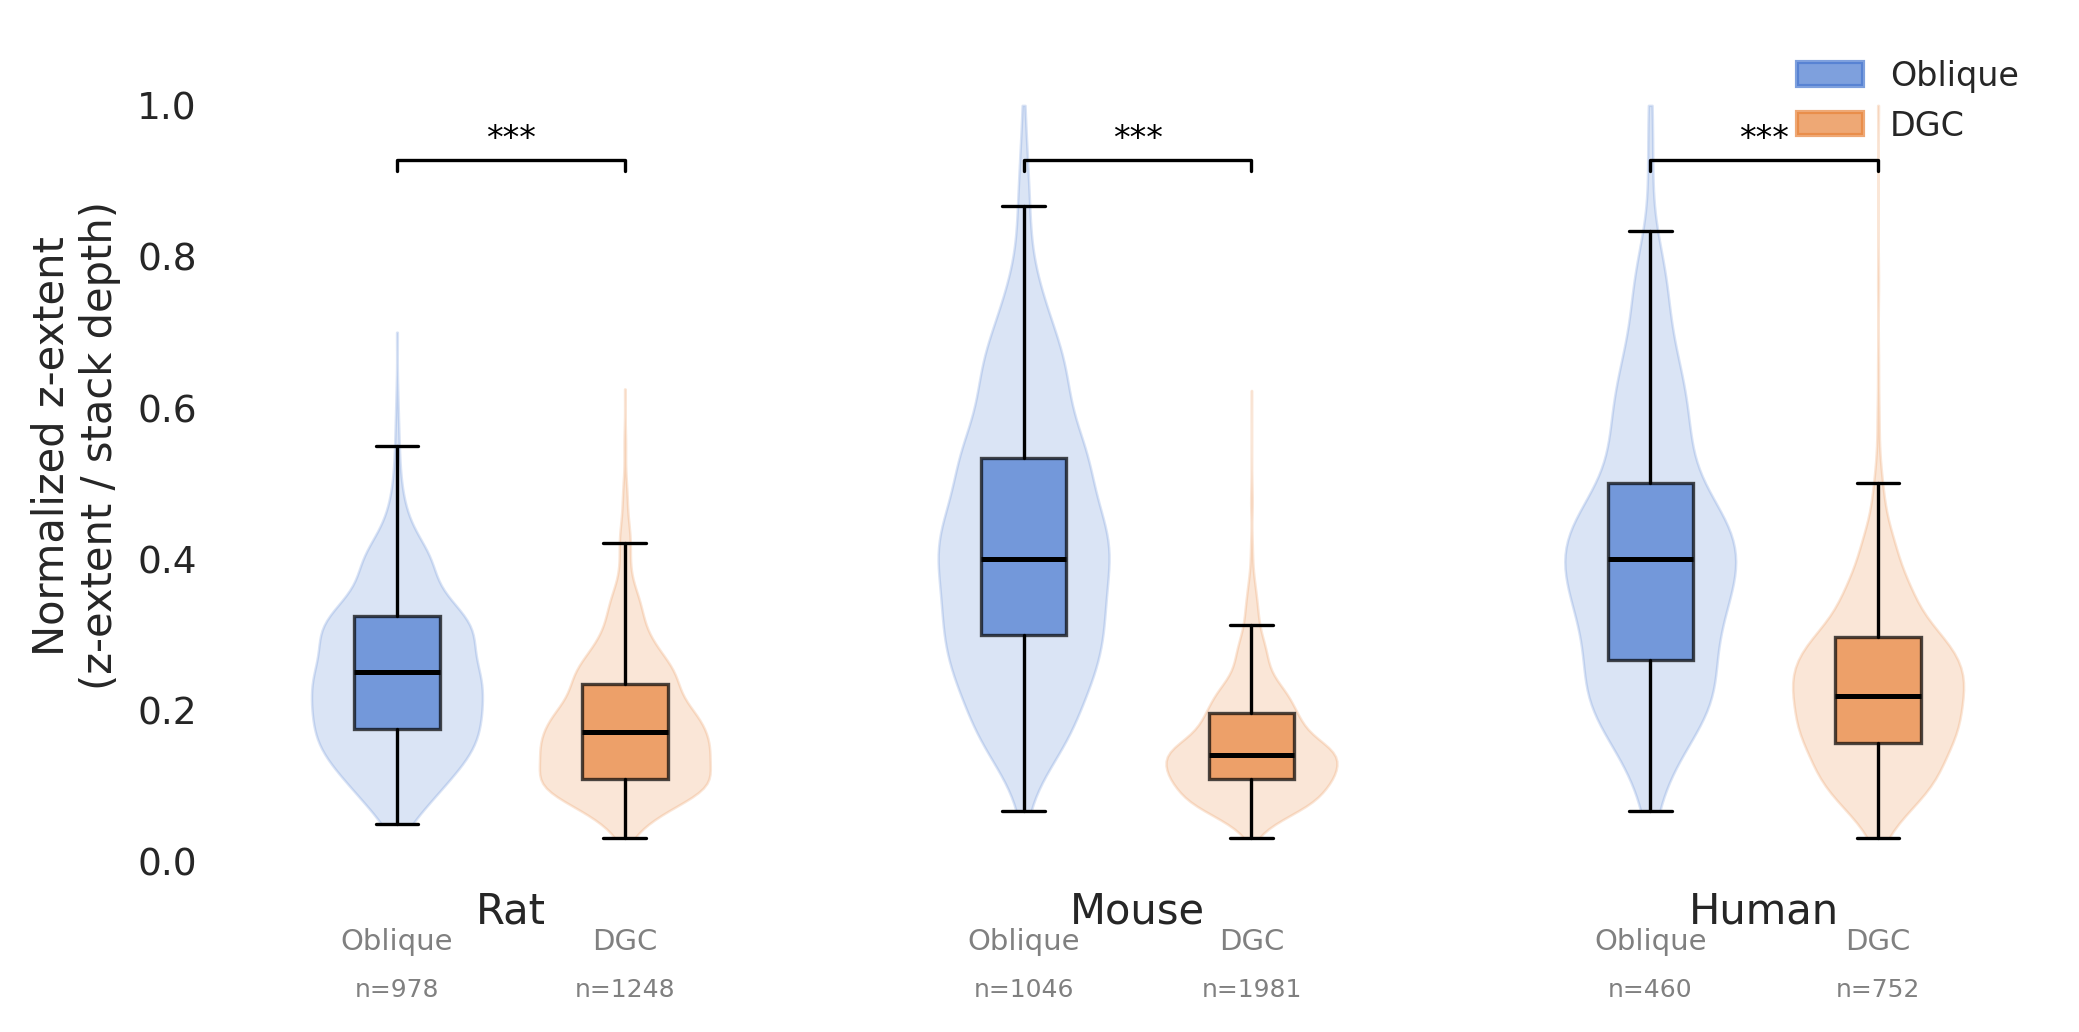

Saved: fig_z_extent_normalized.pdf / .png


In [3]:
"""
fig_z_extent_from_csv.py — Reads pre-collected CSV, plots normalized z-extent.

Reads: z_extent_normalized_all.csv (generated by fig_z_extent.py)

Usage:
    python fig_z_extent_from_csv.py
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.patches import Patch
from scipy.stats import mannwhitneyu

# ═══════════════════════════════════════════════════════════════════════════
#  LOAD CSV
# ═══════════════════════════════════════════════════════════════════════════

csv_path = "z_extent_normalized_all.csv"
df = pd.read_csv(csv_path)
print(f"Loaded {len(df)} neurons from {csv_path}")
print(f"Species: {df['species'].unique()}")
print(f"Modalities: {df['modality'].unique()}")

# ═══════════════════════════════════════════════════════════════════════════
#  PREPARE DATA
# ═══════════════════════════════════════════════════════════════════════════

species_list = ["Rat", "Mouse", "Human"]
labels_order = []
for sp in species_list:
    labels_order.append(f"{sp}\nOblique")
    labels_order.append(f"{sp}\nDGC")

data = {}
for sp in species_list:
    for mod in ["Oblique", "DGC"]:
        key = f"{sp}\n{mod}"
        vals = df[(df["species"] == sp) & (df["modality"] == mod)]["z_extent_normalized"].values
        data[key] = vals
        print(f"  {sp} {mod}: n={len(vals)}, mean={vals.mean():.3f} ± {vals.std():.3f}, "
              f"max={vals.max():.3f}")

# ═══════════════════════════════════════════════════════════════════════════
#  STATISTICS
# ═══════════════════════════════════════════════════════════════════════════

pvalues = {}
for sp in species_list:
    obl = data[f"{sp}\nOblique"]
    dgc = data[f"{sp}\nDGC"]
    U, p = mannwhitneyu(obl, dgc, alternative='two-sided')
    pvalues[sp] = p
    print(f"  {sp}: U={U:.0f}, p={p:.2e}")

# ═══════════════════════════════════════════════════════════════════════════
#  FIGURE
# ═══════════════════════════════════════════════════════════════════════════

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica"],
    "font.size": 9,
    "axes.labelsize": 10,
    "axes.titlesize": 10,
    "xtick.labelsize": 8,
    "ytick.labelsize": 9,
    "legend.fontsize": 8,
    "figure.dpi": 300,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
})

COLOR_OBL = "#4878CF"
COLOR_DGC = "#E8833A"

fig, ax = plt.subplots(figsize=(7, 3.5))

positions = []
pos = 0
for i in range(len(species_list)):
    positions.append(pos)
    positions.append(pos + 0.8)
    pos += 2.2

# Compute ylim FIRST: cover all whisker tips (Q3 + 1.5*IQR)
whisker_tops = []
for label in labels_order:
    q1, q3 = np.percentile(data[label], [25, 75])
    iqr = q3 - q1
    whisker_top = min(q3 + 1.5 * iqr, data[label].max())
    whisker_tops.append(whisker_top)

ylim_top = max(whisker_tops) + 0.12  # room for brackets + stars
ylim_top = np.ceil(ylim_top * 10) / 10  # round up to nearest 0.1

print(f"\nAuto ylim: [0, {ylim_top:.2f}] (max whisker: {max(whisker_tops):.3f})")

# Boxplots FIRST (so violins layer on top correctly)
bp_data = [data[label] for label in labels_order]
bp_colors = [COLOR_OBL if "Oblique" in l else COLOR_DGC for l in labels_order]

bp = ax.boxplot(
    bp_data,
    positions=positions,
    widths=0.3,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(color="black", linewidth=1.2),
    whiskerprops=dict(linewidth=0.8),
    capprops=dict(linewidth=0.8),
    boxprops=dict(linewidth=0.8),
    zorder=3,
)

for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

# Violins — clip to ylim
for i, label in enumerate(labels_order):
    color = COLOR_OBL if "Oblique" in label else COLOR_DGC

    # Clip data to ylim for violin computation
    clipped = data[label][data[label] <= ylim_top]
    if len(clipped) < 2:
        continue

    vp = ax.violinplot(
        clipped,
        positions=[positions[i]],
        widths=0.6,
        showmeans=False,
        showmedians=False,
        showextrema=False,
    )
    for body in vp['bodies']:
        body.set_facecolor(color)
        body.set_alpha(0.2)
        body.set_edgecolor(color)
        body.set_linewidth(0.6)
        body.set_zorder(2)

# Significance brackets
bracket_y = max(whisker_tops) + 0.03

def add_significance(ax, x1, x2, y, p, dy=0.015):
    if p < 1e-10:
        stars = "***"
    elif p < 1e-3:
        stars = "**"
    elif p < 0.05:
        stars = "*"
    else:
        stars = "n.s."
    ax.plot([x1, x1, x2, x2], [y, y + dy, y + dy, y], lw=0.8, color='black',
            clip_on=False)
    ax.text((x1 + x2) / 2, y + dy + 0.005, stars,
            ha='center', va='bottom', fontsize=8, color='black')

for i, sp in enumerate(species_list):
    x1 = positions[i * 2]
    x2 = positions[i * 2 + 1]
    add_significance(ax, x1, x2, bracket_y, pvalues[sp])

# Formatting
ax.set_ylabel("Normalized z-extent\n(z-extent / stack depth)")
ax.set_xticks([positions[i * 2] + 0.4 for i in range(len(species_list))])
ax.set_xticklabels(species_list, fontsize=10)

for i in range(len(labels_order)):
    modality_label = "Oblique" if "Oblique" in labels_order[i] else "DGC"
    ax.text(positions[i], -0.08, modality_label,
            ha='center', va='top', fontsize=7, color='gray',
            transform=ax.get_xaxis_transform())

for i, label in enumerate(labels_order):
    n = len(data[label])
    ax.text(positions[i], -0.14, f"n={n}",
            ha='center', va='top', fontsize=6, color='gray',
            transform=ax.get_xaxis_transform())

ax.set_ylim(0, ylim_top)
ax.set_xlim(-0.6, positions[-1] + 0.6)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_elements = [
    Patch(facecolor=COLOR_OBL, alpha=0.7, edgecolor=COLOR_OBL, label='Oblique'),
    Patch(facecolor=COLOR_DGC, alpha=0.7, edgecolor=COLOR_DGC, label='DGC'),
]
ax.legend(handles=legend_elements, loc='upper right', frameon=False)

plt.tight_layout()
plt.savefig("fig_z_extent_normalized.pdf", bbox_inches='tight')
plt.savefig("fig_z_extent_normalized.png", dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: fig_z_extent_normalized.pdf / .png")